# 시퀀스 의존성 분석
### 핵심 질문: 패스 방향을 결정하는 것은 무엇인가?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import os
os.makedirs('figures', exist_ok=True)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

In [2]:
data_dir = Path('../data/raw')
train = pd.read_csv(data_dir / 'train.csv')
train['result_name'] = train['result_name'].fillna('None')

records = []
for ep, group in train.groupby('game_episode'):
    group = group.sort_values('action_id').reset_index(drop=True)
    n = len(group)
    last = group.iloc[-1]
    if pd.isna(last['end_x']) or pd.isna(last['end_y']):
        continue
    target_dx = last['end_x'] - last['start_x']
    target_dy = last['end_y'] - last['start_y']
    record = {
        'game_episode': ep,
        'ep_length': n,
        'target_dx': target_dx,
        'target_dy': target_dy,
        'last_start_x': last['start_x'],
        'last_start_y': last['start_y'],
        'last_type': last['type_name'],
        'target_dist': np.sqrt(target_dx**2 + target_dy**2),
    }
    for lag in range(1, 4):
        if n >= lag + 1:
            prev = group.iloc[-(lag + 1)]
            if pd.notna(prev['end_x']) and pd.notna(prev['end_y']):
                record[f'lag{lag}_dx'] = prev['end_x'] - prev['start_x']
                record[f'lag{lag}_dy'] = prev['end_y'] - prev['start_y']
                record[f'lag{lag}_type'] = prev['type_name']
            else:
                record[f'lag{lag}_dx'] = np.nan
                record[f'lag{lag}_dy'] = np.nan
                record[f'lag{lag}_type'] = 'None'
        else:
            record[f'lag{lag}_dx'] = np.nan
            record[f'lag{lag}_dy'] = np.nan
            record[f'lag{lag}_type'] = 'None'
    records.append(record)

df = pd.DataFrame(records)
print(f'총 에피소드: {len(df)}')

총 에피소드: 15435


## 시각화 1. 직전 이벤트 이동량(lag-1 dx)과 타겟의 관계
### 이동량 방향에 무관하게 target_dx가 거의 동일한가?

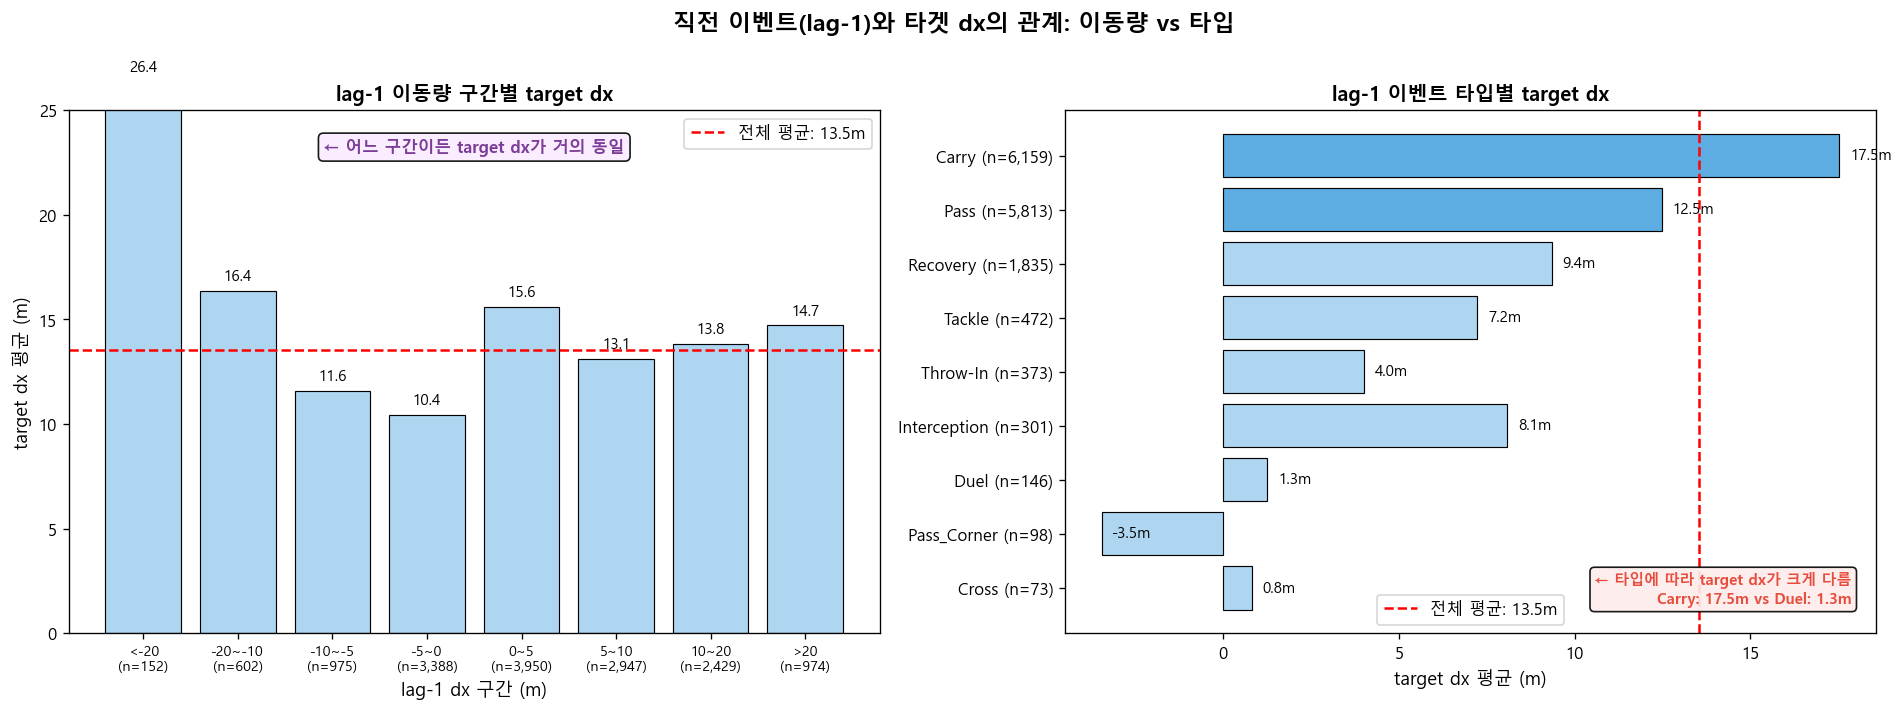

→ lag-1의 이동량(얼마나 움직였나)은 무관, 타입(무엇을 했나)이 핵심


In [3]:
valid = df[['lag1_dx', 'lag1_type', 'target_dx', 'target_dy', 'last_start_x']].dropna()

# lag-1 dx 구간별 target_dx 평균
bins = [-60, -20, -10, -5, 0, 5, 10, 20, 60]
labels = ['<-20', '-20~-10', '-10~-5', '-5~0', '0~5', '5~10', '10~20', '>20']
valid['lag1_bin'] = pd.cut(valid['lag1_dx'], bins=bins, labels=labels)
grouped_lag = valid.groupby('lag1_bin', observed=False).agg(
    mean_target=('target_dx', 'mean'),
    count=('target_dx', 'count')
).reset_index()

# 직전 이벤트 타입별 target_dx 평균
type_stats = valid.groupby('lag1_type').agg(
    mean_target_dx=('target_dx', 'mean'),
    count=('target_dx', 'count')
).reset_index().sort_values('count', ascending=False).head(9)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('직전 이벤트(lag-1)와 타겟 dx의 관계: 이동량 vs 타입', fontsize=14, fontweight='bold')

# 왼쪽: 이동량 구간별
ax1 = axes[0]
colors_left = ['#AED6F1'] * len(grouped_lag)
bars = ax1.bar(range(len(grouped_lag)), grouped_lag['mean_target'],
               color=colors_left, edgecolor='black', linewidth=0.7)
ax1.axhline(valid['target_dx'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'전체 평균: {valid["target_dx"].mean():.1f}m')
ax1.set_xticks(range(len(grouped_lag)))
ax1.set_xticklabels(
    [f'{row["lag1_bin"]}\n(n={row["count"]:,})' for _, row in grouped_lag.iterrows()],
    fontsize=8.5
)
ax1.set_xlabel('lag-1 dx 구간 (m)', fontsize=11)
ax1.set_ylabel('target dx 평균 (m)', fontsize=11)
ax1.set_title('lag-1 이동량 구간별 target dx', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 25)
ax1.legend(fontsize=10)
for bar, val in zip(bars, grouped_lag['mean_target']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax1.text(0.5, 0.92, '← 어느 구간이든 target dx가 거의 동일',
         transform=ax1.transAxes, ha='center', fontsize=10,
         color='#7D3C98', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#F9EBFF', alpha=0.9))

# 오른쪽: 이벤트 타입별
ax2 = axes[1]
type_colors = ['#E74C3C' if v > 20 else '#5DADE2' if v > 12 else '#AED6F1'
               for v in type_stats['mean_target_dx']]
bars2 = ax2.barh(range(len(type_stats)), type_stats['mean_target_dx'],
                 color=type_colors, edgecolor='black', linewidth=0.7)
ax2.axvline(valid['target_dx'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'전체 평균: {valid["target_dx"].mean():.1f}m')
ax2.set_yticks(range(len(type_stats)))
ax2.set_yticklabels(
    [f'{row["lag1_type"]} (n={row["count"]:,})' for _, row in type_stats.iterrows()],
    fontsize=10
)
ax2.invert_yaxis()
ax2.set_xlabel('target dx 평균 (m)', fontsize=11)
ax2.set_title('lag-1 이벤트 타입별 target dx', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
for bar, val in zip(bars2, type_stats['mean_target_dx']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}m', va='center', fontsize=9)
ax2.text(0.97, 0.05, '← 타입에 따라 target dx가 크게 다름\nCarry: 17.5m vs Duel: 1.3m',
         transform=ax2.transAxes, ha='right', va='bottom', fontsize=9,
         color='#E74C3C', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDEDEC', alpha=0.9))

plt.tight_layout()
plt.savefig('figures/lag1_dx_vs_type.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('→ lag-1의 이동량(얼마나 움직였나)은 무관, 타입(무엇을 했나)이 핵심')

## 시각화 2. 현재 필드 위치(start_x)와 타겟 dx의 관계
### 시퀀스 정보 없이 현재 위치만으로 얼마나 설명되는가?

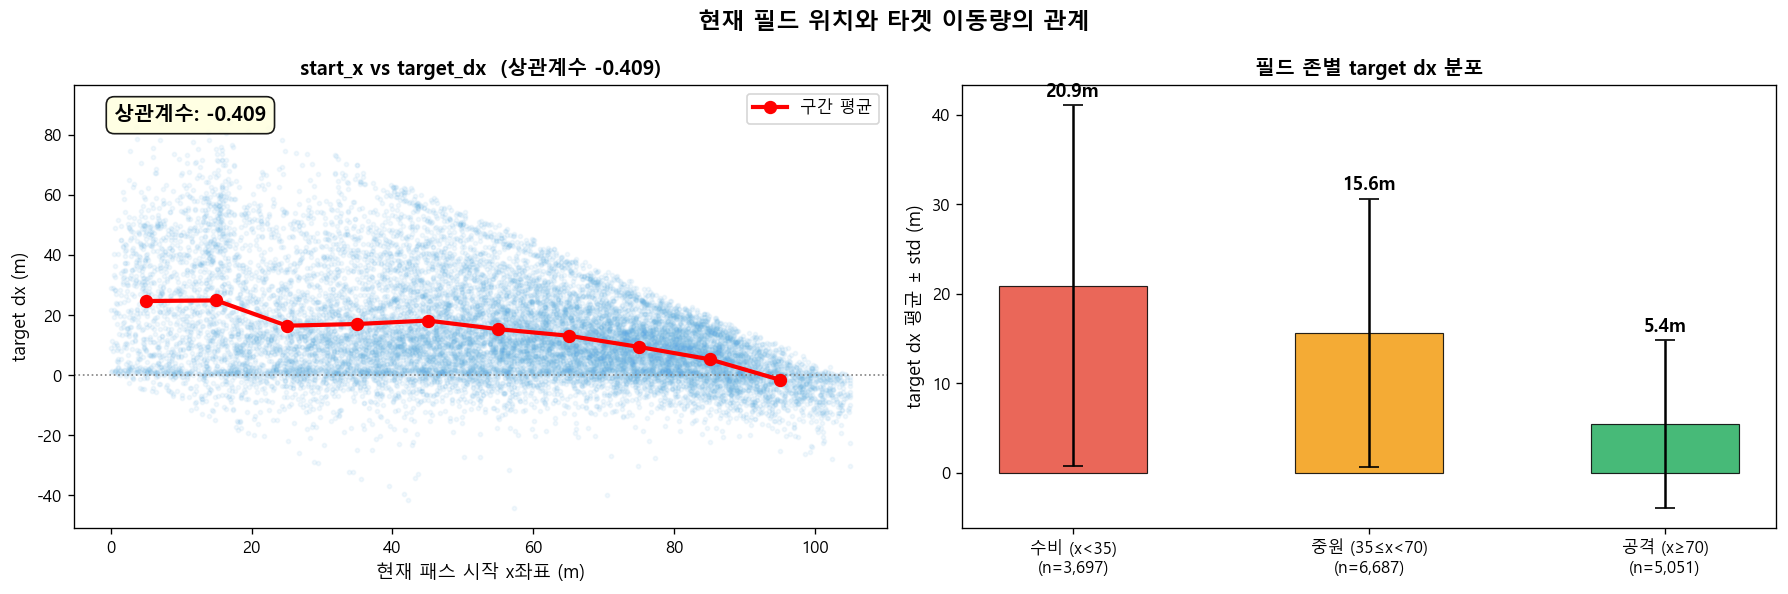

수비 평균 dx: 20.91m
공격 평균 dx: 5.42m
차이: 3.9배


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('현재 필드 위치와 타겟 이동량의 관계', fontsize=14, fontweight='bold')

# 왼쪽: start_x vs target_dx 산점도 + 구간 평균
ax1 = axes[0]
ax1.scatter(df['last_start_x'], df['target_dx'], alpha=0.08, s=6, color='#5DADE2')

bins_x = list(range(0, 106, 10))
df['x_bin'] = pd.cut(df['last_start_x'], bins=bins_x)
bin_means = df.groupby('x_bin', observed=False)['target_dx'].mean()
bin_centers = [(b.left + b.right) / 2 for b in bin_means.index]
ax1.plot(bin_centers, bin_means.values, 'r-o', linewidth=2.5, markersize=7,
         label='구간 평균', zorder=5)

corr = df['last_start_x'].corr(df['target_dx'])
ax1.text(0.05, 0.92, f'상관계수: {corr:.3f}',
         transform=ax1.transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))
ax1.set_xlabel('현재 패스 시작 x좌표 (m)', fontsize=11)
ax1.set_ylabel('target dx (m)', fontsize=11)
ax1.set_title('start_x vs target_dx  (상관계수 -0.409)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.axhline(0, color='gray', linestyle=':', linewidth=1)

# 오른쪽: 필드 존별 target_dx 분포
ax2 = axes[1]
zone_data = {
    '수비 (x<35)': df[df['last_start_x'] < 35]['target_dx'],
    '중원 (35≤x<70)': df[(df['last_start_x'] >= 35) & (df['last_start_x'] < 70)]['target_dx'],
    '공격 (x≥70)': df[df['last_start_x'] >= 70]['target_dx'],
}
zone_colors = ['#E74C3C', '#F39C12', '#27AE60']
zone_means = [d.mean() for d in zone_data.values()]
zone_stds = [d.std() for d in zone_data.values()]
zone_ns = [len(d) for d in zone_data.values()]

positions = range(len(zone_data))
bars = ax2.bar(positions, zone_means, color=zone_colors,
               edgecolor='black', linewidth=0.7, alpha=0.85, width=0.5)
ax2.errorbar(positions, zone_means, yerr=zone_stds,
             fmt='none', color='black', capsize=6, linewidth=1.5)
ax2.set_xticks(positions)
ax2.set_xticklabels(
    [f'{name}\n(n={n:,})' for name, n in zip(zone_data.keys(), zone_ns)],
    fontsize=10
)
ax2.set_ylabel('target dx 평균 ± std (m)', fontsize=11)
ax2.set_title('필드 존별 target dx 분포', fontsize=12, fontweight='bold')
for bar, mean, std in zip(bars, zone_means, zone_stds):
    ax2.text(bar.get_x() + bar.get_width()/2, mean + std + 0.5,
             f'{mean:.1f}m', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/position_vs_target_dx.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'수비 평균 dx: {zone_means[0]:.2f}m')
print(f'공격 평균 dx: {zone_means[2]:.2f}m')
print(f'차이: {zone_means[0]/zone_means[2]:.1f}배')

## 시각화 3. 에피소드 길이(과거 정보량)와 예측 난이도의 관계
### 과거 이벤트가 많을수록 예측이 쉬워지는가?

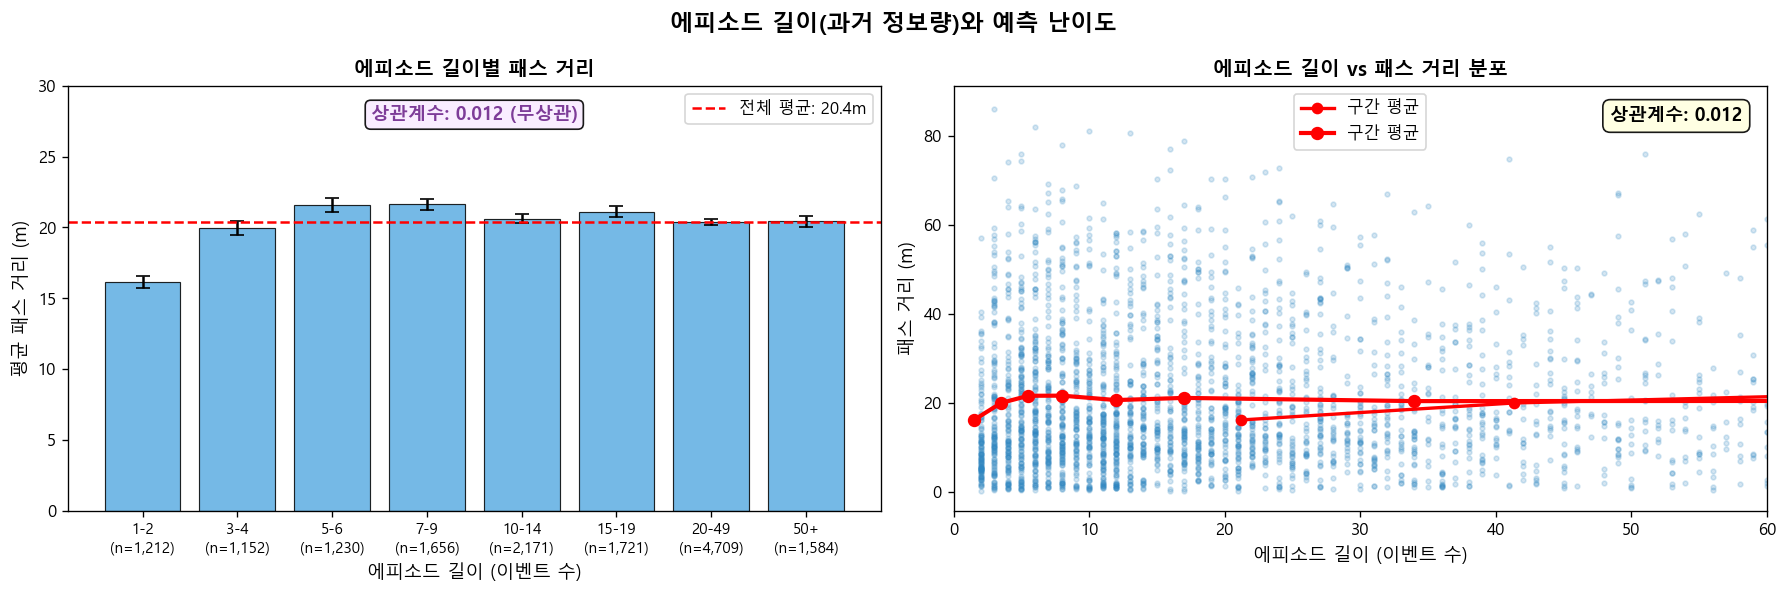

→ 상관계수 0.0121: 과거 정보가 많아도 예측 난이도 변화 없음


In [5]:
# target_dist(패스 거리)를 예측 난이도의 대리 지표로 사용
# (긴 패스 = 불확실성 높음 = 예측 어려움)
bins_len = [0, 3, 5, 7, 10, 15, 20, 50, 300]
labels_len = ['1-2', '3-4', '5-6', '7-9', '10-14', '15-19', '20-49', '50+']
df['length_bin'] = pd.cut(df['ep_length'], bins=bins_len, labels=labels_len)

grouped_len = df.groupby('length_bin', observed=False).agg(
    mean_dist=('target_dist', 'mean'),
    std_dist=('target_dist', 'std'),
    mean_dx=('target_dx', 'mean'),
    count=('ep_length', 'count')
).reset_index()

corr_len_dist = df['ep_length'].corr(df['target_dist'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('에피소드 길이(과거 정보량)와 예측 난이도', fontsize=14, fontweight='bold')

# 왼쪽: 에피소드 길이별 패스 거리 평균
ax1 = axes[0]
bars = ax1.bar(range(len(grouped_len)), grouped_len['mean_dist'],
               color='#5DADE2', edgecolor='black', linewidth=0.7, alpha=0.85)
ax1.errorbar(range(len(grouped_len)), grouped_len['mean_dist'],
             yerr=grouped_len['std_dist'] / np.sqrt(grouped_len['count']),
             fmt='none', color='black', capsize=4)
ax1.axhline(df['target_dist'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'전체 평균: {df["target_dist"].mean():.1f}m')
ax1.set_xticks(range(len(grouped_len)))
ax1.set_xticklabels(
    [f'{row["length_bin"]}\n(n={row["count"]:,})' for _, row in grouped_len.iterrows()],
    fontsize=9
)
ax1.set_xlabel('에피소드 길이 (이벤트 수)', fontsize=11)
ax1.set_ylabel('평균 패스 거리 (m)', fontsize=11)
ax1.set_title('에피소드 길이별 패스 거리', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 30)
ax1.legend(fontsize=10)
ax1.text(0.5, 0.92, f'상관계수: {corr_len_dist:.3f} (무상관)',
         transform=ax1.transAxes, ha='center', fontsize=11, fontweight='bold',
         color='#7D3C98',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#F9EBFF', alpha=0.9))

# 오른쪽: 산점도
ax2 = axes[1]
sample = df.sample(3000, random_state=42)
ax2.scatter(sample['ep_length'], sample['target_dist'],
            alpha=0.2, s=8, color='#2E86C1')
ax2.plot(grouped_len['count'].cumsum() / grouped_len['count'].sum() * df['ep_length'].max(),
         grouped_len['mean_dist'], 'r-o', linewidth=2, markersize=6, label='구간 평균')

# 실제 구간 중앙값으로 재계산
bin_mid = [1.5, 3.5, 5.5, 8, 12, 17, 34, 70]
ax2.plot(bin_mid, grouped_len['mean_dist'].values, 'r-o',
         linewidth=2.5, markersize=7, label='구간 평균', zorder=5)

ax2.text(0.97, 0.95, f'상관계수: {corr_len_dist:.3f}',
         transform=ax2.transAxes, ha='right', va='top',
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))
ax2.set_xlabel('에피소드 길이 (이벤트 수)', fontsize=11)
ax2.set_ylabel('패스 거리 (m)', fontsize=11)
ax2.set_title('에피소드 길이 vs 패스 거리 분포', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 60)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/episode_length_vs_difficulty.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'→ 상관계수 {corr_len_dist:.4f}: 과거 정보가 많아도 예측 난이도 변화 없음')

## 종합 요약

In [6]:
print('=' * 65)
print('분석 요약: 패스 방향을 결정하는 것은 무엇인가')
print('=' * 65)

print('\n[1] lag-1 이동량(dx) 방향별 target_dx')
fwd = valid[valid['lag1_dx'] > 5]['target_dx'].mean()
bwd = valid[valid['lag1_dx'] < -5]['target_dx'].mean()
neu = valid[(valid['lag1_dx'] >= -5) & (valid['lag1_dx'] <= 5)]['target_dx'].mean()
print(f'  전진(>5m): {fwd:.2f}m  후진(<-5m): {bwd:.2f}m  정체: {neu:.2f}m')
print('  → 어느 방향으로 얼마나 움직였든 target_dx 거의 동일 → 이동량은 무관')

print('\n[2] lag-1 이벤트 타입별 target_dx')
type_result = valid.groupby('lag1_type')['target_dx'].mean().sort_values(ascending=False)
for t, v in type_result.head(5).items():
    print(f'  {t}: {v:.2f}m')
print('  → 타입에 따라 target_dx가 크게 달라짐 → 종류가 핵심')

print('\n[3] 현재 위치와 target_dx 상관계수')
print(f'  last_start_x → target_dx: {df["last_start_x"].corr(df["target_dx"]):.4f}')
print(f'  수비 평균 dx: {zone_means[0]:.1f}m  공격 평균 dx: {zone_means[2]:.1f}m')
print('  → 현재 위치가 가장 강한 단일 예측 변수')

print('\n[4] 에피소드 길이 vs 예측 난이도')
print(f'  상관계수: {corr_len_dist:.4f} → 과거 정보량과 무관')

print('\n[결론]')
print('  패스 방향을 결정하는 것은 과거 이동 시퀀스가 아니다.')
print('  현재 필드 위치 + 직전 이벤트 타입이 핵심 신호다.')
print('  시퀀스 모델의 장기 의존성 포착 능력이 이 문제에서 작동하지 않는 이유다.')

분석 요약: 패스 방향을 결정하는 것은 무엇인가

[1] lag-1 이동량(dx) 방향별 target_dx
  전진(>5m): 13.64m  후진(<-5m): 14.55m  정체: 13.22m
  → 어느 방향으로 얼마나 움직였든 target_dx 거의 동일 → 이동량은 무관

[2] lag-1 이벤트 타입별 target_dx
  Clearance: 62.42m
  Catch: 49.04m
  Intervention: 22.06m
  Carry: 17.54m
  Goal Kick: 16.89m
  → 타입에 따라 target_dx가 크게 달라짐 → 종류가 핵심

[3] 현재 위치와 target_dx 상관계수
  last_start_x → target_dx: -0.4094
  수비 평균 dx: 20.9m  공격 평균 dx: 5.4m
  → 현재 위치가 가장 강한 단일 예측 변수

[4] 에피소드 길이 vs 예측 난이도
  상관계수: 0.0121 → 과거 정보량과 무관

[결론]
  패스 방향을 결정하는 것은 과거 이동 시퀀스가 아니다.
  현재 필드 위치 + 직전 이벤트 타입이 핵심 신호다.
  시퀀스 모델의 장기 의존성 포착 능력이 이 문제에서 작동하지 않는 이유다.
